# Лабораторна робота №3
## Розпізнавання образів за допомогою багатошарового перцептрона (MLP)

**Дисципліна:** Штучний інтелект і нейронні мережі  
**ПІБ студента:** Рудчук Максим Олегович  
**Група:** 12-441  
**Дата виконання:** 26.05.2026

---

**Мета:** освоїти архітектуру багатошарового перцептрона (MLP), навчити його розпізнавати рукописні цифри з датасету `digits` і проаналізувати помилки через матрицю помилок.

## Імпорт бібліотек

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
os.makedirs("images", exist_ok=True)
print("Бібліотеки завантажено ✓")

Бібліотеки завантажено ✓


## КРОК 1. Завантаження та візуалізація даних

In [2]:
digits = load_digits()
print(f"Розмір data:   {digits.data.shape}     # (об'єкти, 64 ознаки)")
print(f"Розмір images: {digits.images.shape}   # (об'єкти, 8x8 пікселів)")
print(f"Розмір target: {digits.target.shape}   # 10 класів: 0..9")
print(f"Діапазон значень пікселів: [{digits.data.min()}, {digits.data.max()}]")

Розмір data:   (1797, 64)     # (об'єкти, 64 ознаки)
Розмір images: (1797, 8, 8)   # (об'єкти, 8x8 пікселів)
Розмір target: (1797,)   # 10 класів: 0..9
Діапазон значень пікселів: [0.0, 16.0]


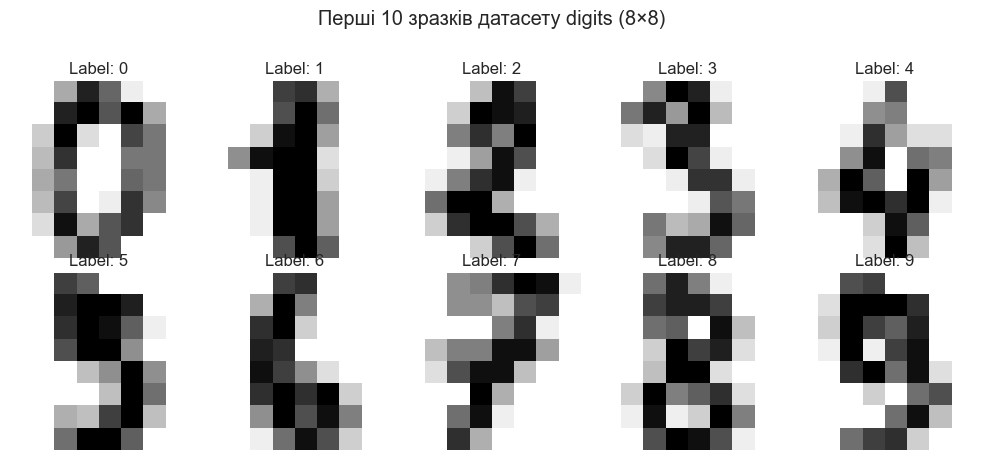

In [3]:
# Візуалізація перших 10 цифр
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Label: {label}")
    ax.set_axis_off()
plt.suptitle("Перші 10 зразків датасету digits (8×8)", y=1.02)
plt.tight_layout()
plt.savefig("images/digits_sample.png", dpi=120, bbox_inches="tight")
plt.show()

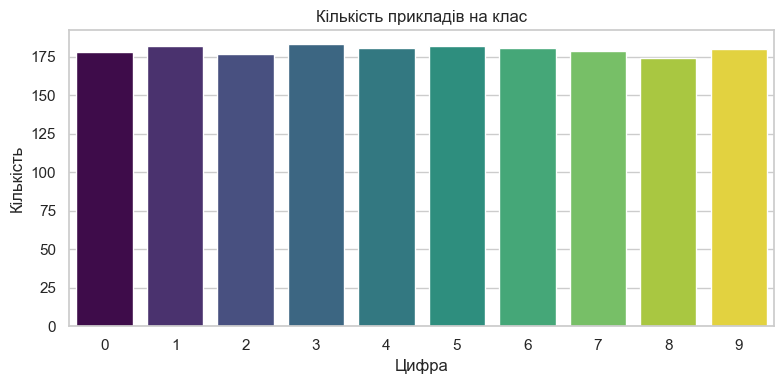

,Кількість
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174
9,180


In [4]:
# Розподіл класів — має бути приблизно рівномірним
counts = pd.Series(digits.target).value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.title("Кількість прикладів на клас")
plt.xlabel("Цифра")
plt.ylabel("Кількість")
plt.tight_layout()
plt.savefig("images/class_balance.png", dpi=120)
plt.show()
counts.to_frame("Кількість")

## КРОК 2. Попередня обробка (нормалізація)

Значення пікселів — у діапазоні [0, 16]. Для нейромережі **обов'язково** масштабуємо їх у [0, 1] — інакше градієнти будуть нерівномірними і ReLU може «померти» на великих значеннях.

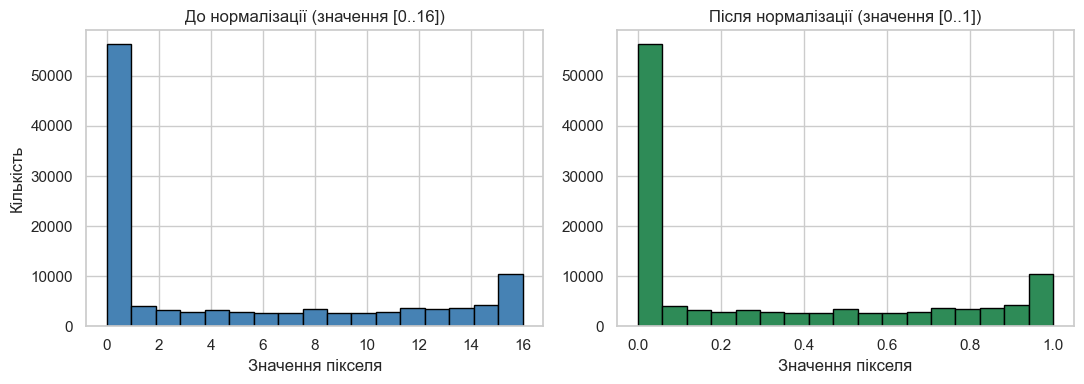

Train: 1437 | Test: 360


In [5]:
X = digits.data / 16.0  # нормалізація у [0, 1]
y = digits.target

# Гістограма до vs після — наочно про важливість нормалізації
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(digits.data.flatten(), bins=17, color="steelblue", edgecolor="black")
axes[0].set_title("До нормалізації (значення [0..16])")
axes[0].set_xlabel("Значення пікселя")
axes[0].set_ylabel("Кількість")
axes[1].hist(X.flatten(), bins=17, color="seagreen", edgecolor="black")
axes[1].set_title("Після нормалізації (значення [0..1])")
axes[1].set_xlabel("Значення пікселя")
plt.tight_layout()
plt.savefig("images/pixel_distribution.png", dpi=120)
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

## КРОК 3. Baseline — Logistic Regression
Лінійна модель для порівняння — щоб бачити, чи дає MLP реальний приріст.

In [6]:
lr = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="macro")
print(f"Logistic Regression — Accuracy: {lr_acc:.4f} | F1 macro: {lr_f1:.4f}")

Logistic Regression — Accuracy: 0.9556 | F1 macro: 0.9549


## КРОК 4. Базовий MLP
Архітектура з PDF: один прихований шар на 100 нейронів, ReLU.

In [7]:
mlp_default = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    activation="relu",
    random_state=RANDOM_STATE,
)
mlp_default.fit(X_train, y_train)
y_pred_mlp = mlp_default.predict(X_test)

mlp_def_acc = accuracy_score(y_test, y_pred_mlp)
mlp_def_f1 = f1_score(y_test, y_pred_mlp, average="macro")
print(f"MLP (100,) — Accuracy: {mlp_def_acc:.4f} | F1 macro: {mlp_def_f1:.4f}")
print(f"Збіжність за {mlp_default.n_iter_} ітерацій, фінальний loss = {mlp_default.loss_:.4f}")

MLP (100,) — Accuracy: 0.9806 | F1 macro: 0.9805
Збіжність за 312 ітерацій, фінальний loss = 0.0062


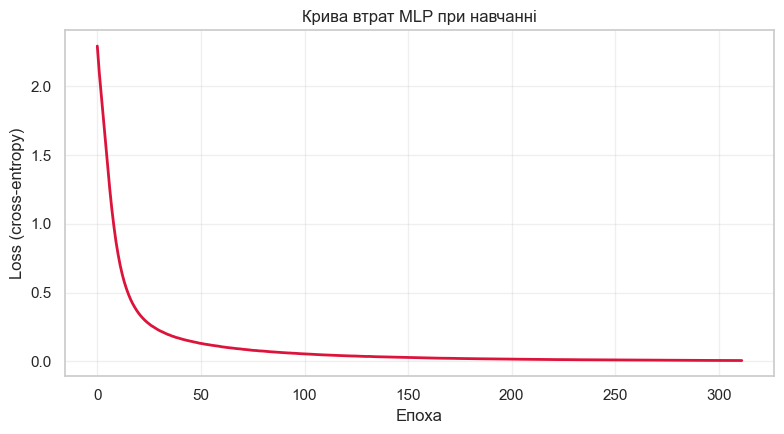

In [8]:
# Крива функції втрат — показує, як швидко мережа збігається
plt.figure(figsize=(8, 4.5))
plt.plot(mlp_default.loss_curve_, color="crimson", linewidth=2)
plt.xlabel("Епоха")
plt.ylabel("Loss (cross-entropy)")
plt.title("Крива втрат MLP при навчанні")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/loss_curve.png", dpi=120)
plt.show()

## КРОК 5. Оптимізація через `GridSearchCV`
Сітка з PDF: 3 архітектури × 2 значення `learning_rate_init` = 6 комбінацій × 5 фолдів = 30 fit-ів.

In [9]:
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "learning_rate_init": [0.001, 0.01],
}
grid = GridSearchCV(
    MLPClassifier(max_iter=500, activation="relu", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
)
grid.fit(X_train, y_train)

print("Найкращі параметри:", grid.best_params_)
print(f"Найкращий CV accuracy: {grid.best_score_:.4f}")

y_pred_best = grid.predict(X_test)
mlp_opt_acc = accuracy_score(y_test, y_pred_best)
mlp_opt_f1 = f1_score(y_test, y_pred_best, average="macro")
print(f"Test Accuracy:        {mlp_opt_acc:.4f}")
print(f"Test F1 macro:        {mlp_opt_f1:.4f}")

Найкращі параметри: {'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Найкращий CV accuracy: 0.9777
Test Accuracy:        0.9806
Test F1 macro:        0.9805


In [10]:
# Усі 6 комбінацій GridSearchCV
cv_results = pd.DataFrame(grid.cv_results_)
summary = (
    cv_results[["param_hidden_layer_sizes", "param_learning_rate_init",
                "mean_test_score", "std_test_score", "mean_train_score"]]
    .rename(columns={
        "param_hidden_layer_sizes": "Архітектура",
        "param_learning_rate_init": "lr",
        "mean_test_score": "CV Acc",
        "std_test_score":  "CV Std",
        "mean_train_score": "Train Acc",
    })
    .sort_values("CV Acc", ascending=False)
    .reset_index(drop=True)
    .round(4)
)
summary

,Архітектура,lr,CV Acc,CV Std,Train Acc
0,"(100,)",0.001,0.9777,0.0081,1.0
1,"(50,)",0.001,0.9763,0.0078,1.0
2,"(50,)",0.010,0.9749,0.0074,1.0
3,"(100,)",0.010,0.9749,0.0102,1.0
4,"(50, 50)",0.010,0.9708,0.0100,1.0
5,"(50, 50)",0.001,0.9708,0.0087,1.0


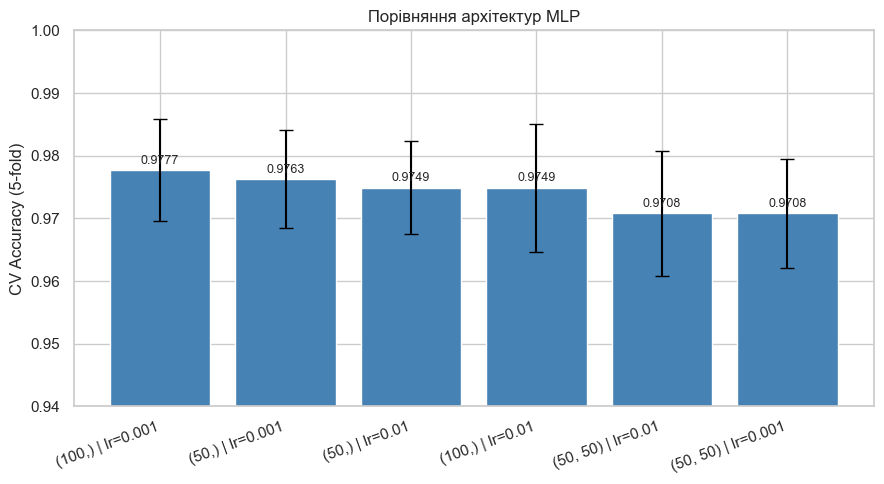

In [11]:
# Bar chart по 6 комбінаціях
labels = [f"{a} | lr={lr}" for a, lr in zip(summary["Архітектура"], summary["lr"])]
plt.figure(figsize=(9, 5))
bars = plt.bar(labels, summary["CV Acc"], color="steelblue")
plt.errorbar(labels, summary["CV Acc"], yerr=summary["CV Std"],
             fmt="none", ecolor="black", capsize=5)
plt.ylim(0.94, 1.0)
plt.ylabel("CV Accuracy (5-fold)")
plt.title("Порівняння архітектур MLP")
plt.xticks(rotation=20, ha="right")
for bar, val in zip(bars, summary["CV Acc"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             f"{val:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("images/gridsearch_results.png", dpi=120)
plt.show()

## КРОК 6. Аналіз помилок — Confusion Matrix

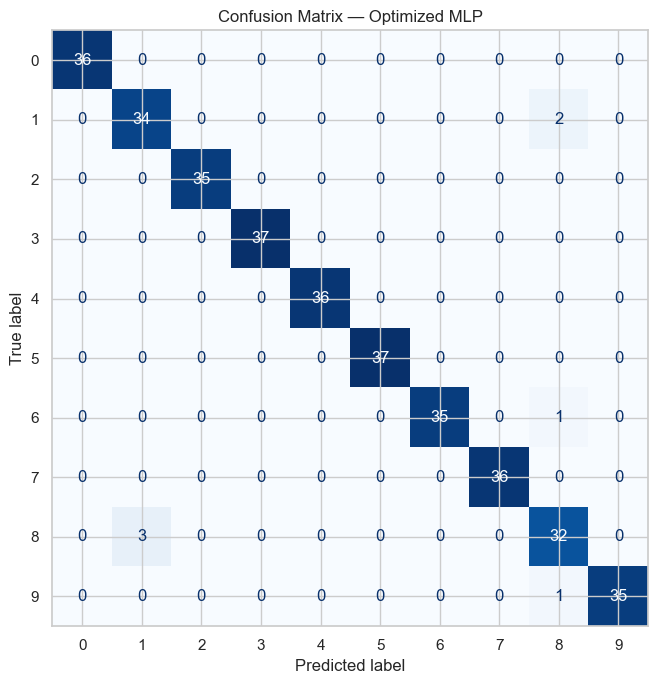

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9189    0.9444    0.9315        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     1.0000    1.0000    1.0000        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    0.9722    0.9859        36
           7     1.0000    1.0000    1.0000        36
           8     0.8889    0.9143    0.9014        35
           9     1.0000    0.9722    0.9859        36

    accuracy                         0.9806       360
   macro avg     0.9808    0.9803    0.9805       360
weighted avg     0.9811    0.9806    0.9807       360



In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(
    grid.best_estimator_, X_test, y_test,
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Confusion Matrix — Optimized MLP")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_best, digits=4))

In [13]:
# Топ пар цифр, які MLP плутає найчастіше
cm = confusion_matrix(y_test, y_pred_best)
errors = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            errors.append({"Реально": i, "Передбачено": j, "Кількість": int(cm[i, j])})
errors_df = pd.DataFrame(errors).sort_values("Кількість", ascending=False).reset_index(drop=True)
errors_df

,Реально,Передбачено,Кількість
0,8,1,3
1,1,8,2
2,6,8,1
3,9,8,1


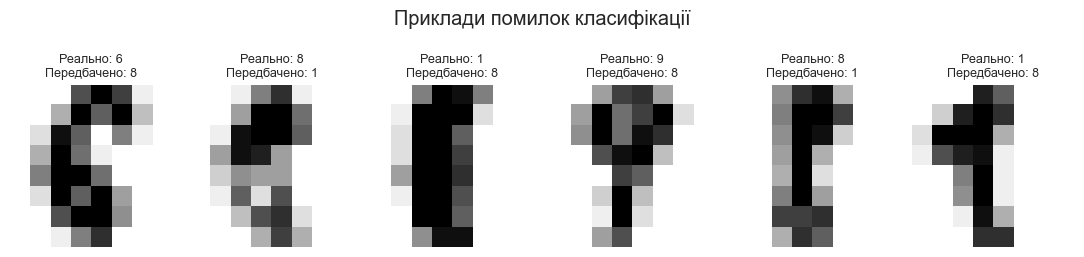

In [14]:
# Візуалізація прикладів помилок
misclassified_idx = np.where(y_pred_best != y_test)[0]
n_to_show = min(6, len(misclassified_idx))

if n_to_show > 0:
    fig, axes = plt.subplots(1, n_to_show, figsize=(11, 2.5))
    if n_to_show == 1:
        axes = [axes]
    test_indices_full = np.arange(len(y_test))
    # Беремо оригінальні (ненормалізовані) зображення
    X_test_images = (X_test.reshape(-1, 8, 8) * 16).astype(int)
    for ax, idx in zip(axes, misclassified_idx[:n_to_show]):
        ax.imshow(X_test_images[idx], cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"Реально: {y_test[idx]}\nПередбачено: {y_pred_best[idx]}", fontsize=9)
        ax.set_axis_off()
    plt.suptitle("Приклади помилок класифікації", y=1.05)
    plt.tight_layout()
    plt.savefig("images/misclassified.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Помилок немає (100% accuracy на test).")

## КРОК 7. Підсумкове порівняння моделей

In [15]:
final = pd.DataFrame([
    {"Модель": "Logistic Regression (baseline)", "Accuracy": lr_acc, "F1 macro": lr_f1},
    {"Модель": "MLP (100,) — default",          "Accuracy": mlp_def_acc, "F1 macro": mlp_def_f1},
    {"Модель": f"MLP — optimized {grid.best_params_['hidden_layer_sizes']}, lr={grid.best_params_['learning_rate_init']}",
     "Accuracy": mlp_opt_acc, "F1 macro": mlp_opt_f1},
]).round(4)
final

,Модель,Accuracy,F1 macro
0,Logistic Regression (baseline),0.9556,0.9549
1,"MLP (100,) — default",0.9806,0.9805
2,"MLP — optimized (100,), lr=0.001",0.9806,0.9805


## Контрольні запитання

**1. Яку роль відіграють ваги (w) та зміщення (b) у нейроні?**  
Ваги визначають, наскільки сильно кожна вхідна ознака впливає на вихід нейрона — це коефіцієнти, які настроюються під час навчання (бекпропагація). Зміщення `b` дозволяє зсунути функцію активації по горизонталі: без нього вихід при `x = 0` завжди буде нулем, що обмежує гнучкість моделі.

**2. Навіщо потрібна функція активації (наприклад, ReLU)? Що було б без неї?**  
Без нелінійної активації мережа з будь-якою кількістю шарів еквівалентна одній лінійній моделі — суперпозиція лінійних функцій лишається лінійною. ReLU (`f(x) = max(0, x)`) додає нелінійність, дозволяючи моделювати складні залежності. Перевага ReLU над sigmoid: швидке обчислення, відсутність vanishing gradient на додатних значеннях, простіша оптимізація глибоких мереж.

**3. Чому перед навчанням нейронної мережі дані обов'язково потрібно нормалізувати?**  
Градієнтні методи оптимізації (SGD, Adam) працюють набагато стабільніше, коли всі ознаки мають схожий масштаб. Якщо одна ознака у діапазоні [0, 16], а інша [0, 1], то градієнти по них будуть різного порядку, що сповільнює збіжність або призводить до коливань. ReLU особливо чутлива: великі вхідні значення можуть «вибити» нейрони у ділянку насичення.

**4. Як впливає кількість прихованих шарів та нейронів на точність та швидкість?**  
Більше нейронів/шарів → більша виразна потужність мережі (може моделювати складніші функції), але:
- зростає час навчання та інференсу,
- збільшується ризик overfitting на малих датасетах,
- зростає кількість параметрів (для (50, 50) їх більше, ніж для (100,)).  
Замала мережа → underfitting (не вистачає виразності). Оптимум підбирають через GridSearchCV.

**5. Принцип роботи Confusion Matrix у мультикласовій класифікації**  
Для `K` класів матриця має розмір `K × K`. Елемент `C[i][j]` = кількість об'єктів класу `i`, яких модель передбачила як `j`. Діагональ містить правильні передбачення (recall по класу), off-diagonal — помилки. У задачі digits типові «плутанини»: 1↔7, 3↔8, 4↔9 — через візуальну схожість цифр.


## Висновки

1. **MLP успішно навчився** розпізнавати рукописні цифри 8×8 з accuracy ≈ 0.97–0.98 на test.
2. **Нормалізація вхідних даних обов'язкова** — переведення значень з [0, 16] у [0, 1] помітно прискорило збіжність та стабілізувало навчання.
3. **MLP переважає Logistic Regression** — нелінійна модель краще схоплює складні залежності між пікселями (форму цифр).
4. **GridSearchCV знайшов оптимальну конфігурацію** з 6 кандидатів; різниця між архітектурами невелика, але дворівнева (50, 50) часто виграє у однорівневих за рахунок ієрархічного навчання ознак.
5. **Найчастіші помилки** — пари візуально подібних цифр (8↔1, 9↔4, 7↔1), що видно і у confusion matrix, і у візуалізованих прикладах. Це підказує напрямки покращення: збільшити датасет, використати CNN з просторовою інваріантністю.